<a href="https://colab.research.google.com/github/jamesriddellv/2026-Viromics-Practicals/blob/main/day1_and_2_Bioreactor_viruses_deep_dive_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup

In [1]:
# Clone the github repository to access the data and helper functions within colab.
!git clone https://github.com/jamesriddellv/2026-Viromics-Practicals.git

Cloning into '2026-Viromics-Practicals'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 71 (delta 33), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 5.29 MiB | 13.00 MiB/s, done.
Resolving deltas: 100% (33/33), done.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

# custom set of functions so that we don't overwhelm the notebook with unecessary blocks of code, and avoid installing large packages like skbio.
import sys
sys.path.append('./2026-Viromics-Practicals')
import stats_helpers as sh


# set fonts and ensure PDF text is editable:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'

In [3]:
# Set to the directory you uploaded the data to
import os

# Base directory for practicals
base_dir = './2026-Viromics-Practicals'

# Set data directory path
data_dir = os.path.join(base_dir, 'data')

# Verify the path exists
print("Data directory:", data_dir)
print("Files in data folder:", os.listdir(data_dir))

Data directory: ./2026-Viromics-Practicals/data
Files in data folder: ['cleaned_getmm_by_predicted_host.csv', '.DS_Store', 'alpha_diversity_metadata.csv', 'genomad_checkv_metadata.csv', 'contig_591846.fna', 'contig_591846_annotations.tsv', 'final_assignments.csv', 'contig_591846.gff', 'votu_relative_abundance.csv', 'genomad_checkv_dramv_metadata.csv', 'getmms_REV_5x_vOTUs_corrected_wide.tsv', 'metaT_sample_metadata.csv', 'cleaned_getmm_by_predicted_host_additional_predictions.csv', 'Host_prediction_to_genome_m90.csv']


# Introduction

Human activities are accelerating permafrost thaw and subsequent methane emissions from increased microbial activity, prompting microbiome engineering efforts as an emissions mitigation strategy.

It was recently demonstrated that catechin, a polyphenol subunit of condensed tannin commonly found in tea leaves, could drastically reduce methane emissions (>80%) in thawed permafrost microcosms by enriching catechin-degrading prokaryotes that outcompeted methanogens for hydrogen.

However, viral contributions to such microbiome-level responses remain unexplored.

Your goals are to answer:
1. Does catechin alter virus community activity? If so, by what timepoint is a treatment effect observed?
2. Which host MAGs are these vOTUs predicted to infect? Do the most active vOTUs infect catechin-degrading MAGs?
3. What kind of viruses are the most active vOTUs in these samples? What genes do these viruses encode? Are they lytic or lysogenic?

Today, we will focus on the first step, which covers identification of viruses from assembled short-reads of bulk metagenomic data.

We will not be covering the actual running of the tools (requires too much time to install programs + databases). We will cover how to perform exploratory data analysis of tool outputs and how to interpret them.

Please ask questions and modify the code or use AI-assisted coding to further explore the data within the notebook! This workshop is for you, and the instructors are here to answer any questions you have so that you can get jumpstarted with your own viromics projects!

# Part 1: Virus Identification

The cell below will load in GeNomad and CheckV summary outputs that have been merged per viral contig identified. GeNomad was run first to identify viral contigs, then CheckV was run on those viral contigs to get additional quality control statistics.

There is some additional information in the comments (lines that start with #) to show which columns belong to which tool output, and the file name where you can find them if you ran these tools on your own dataset.

In [4]:
# <-- Run this cell by pressing the play button.
# Text preceded with a '#' are comments and will not execute

# Read in virus identification metadata, a merged table of genomad and checkv outputs
file_name = 'genomad_checkv_metadata.csv'
path = '/'.join([data_dir, file_name])
df = pd.read_csv(path)
df.head()

# Genomad summary output columns, from <basename>.fasta/<basename>_vOTUs_summary/<basename>_vOTUs_virus_summary.tsv
# where <basename> is the input fasta file name before the .fasta/.fna/.fa extension.
# 'vOTU', 'length', 'topology', 'coordinates', 'n_genes', 'genetic_code',
# 'virus_score', 'fdr', 'n_hallmarks', 'marker_enrichment', 'taxonomy',

# CheckV summary output columns, from <checkv_outDir>/quality_summary.tsv
# 'contig_length', 'provirus', 'proviral_length', 'gene_count',
# 'viral_genes', 'host_genes', 'checkv_quality', 'miuvig_quality',
# 'completeness', 'completeness_method', 'contamination', 'kmer_freq',
# 'warnings', 'is_provirus_aggregated'

# See the full code to produce these files at https://github.com/jamesriddellv/Grantham_Bioreactor/tree/main/01-build-vOTU-database/scripts
# If you plan on running virus identification in a future project, my advice is
# do yourself a favor and rename your contig headers to
# simple identifiers (contig_XXXX). I did this for this project and it made it
# so much easier to join datasets and process contigs through multiple different
# tools. Many tools get angry about delimiters inserted by other tools.
# Keeping files that contain mappings from new contig IDs to the names in the
# original sequencing/assembly outputs is best practice!
df

,vOTU,length,topology,coordinates,n_genes,genetic_code,virus_score,fdr,n_hallmarks,marker_enrichment,...,viral_genes,host_genes,checkv_quality,miuvig_quality,completeness,completeness_method,contamination,kmer_freq,warnings,is_provirus_aggregated
0,contig_1172261,14107,No terminal repeats,NaN,18,11,0.9998,0.0002,6,15.8474,...,6,0,Low-quality,Genome-fragment,31.74,AAI-based (medium-confidence),0.0,1.0,NaN,False
1,contig_1172211,20579,No terminal repeats,NaN,27,11,0.9998,0.0002,2,7.0860,...,6,0,Low-quality,Genome-fragment,15.39,AAI-based (medium-confidence),0.0,1.0,NaN,False
2,contig_1171976,82624,No terminal repeats,NaN,71,11,0.9996,0.0002,5,25.7779,...,8,2,Low-quality,Genome-fragment,38.35,AAI-based (high-confidence),0.0,1.0,NaN,False
3,contig_1172178,23274,No terminal repeats,NaN,25,11,0.9994,0.0003,2,6.9207,...,4,0,Low-quality,Genome-fragment,24.72,AAI-based (medium-confidence),0.0,1.0,NaN,False
4,contig_1171503|provirus_3_42032,42030,Provirus,3-42032,55,11,0.9986,0.0004,9,27.4984,...,10,2,Medium-quality,Genome-fragment,55.00,HMM-based (lower-bound),0.0,1.0,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,contig_1167747,22884,No terminal repeats,NaN,19,11,0.8233,0.0051,2,9.4482,...,2,2,Low-quality,Genome-fragment,29.52,HMM-based (lower-bound),0.0,1.0,NaN,False
896,contig_1167982,5620,No terminal repeats,NaN,6,11,0.8129,0.0053,1,3.1972,...,1,0,Low-quality,Genome-fragment,12.17,AAI-based (medium-confidence),0.0,1.0,NaN,False
897,contig_1169753,29890,No terminal repeats,NaN,27,11,0.7751,0.0058,2,2.7956,...,2,3,Low-quality,Genome-fragment,44.71,HMM-based (lower-bound),0.0,1.0,NaN,False
898,contig_1166240,5659,No terminal repeats,NaN,4,11,0.7654,0.0060,2,3.4166,...,2,0,Low-quality,Genome-fragment,8.50,HMM-based (lower-bound),0.0,1.0,NaN,False


OK great. We've identified some active viruses (see methods) from 100s of millions of contigs. Yay! But how do we get a sense for how "good" these virus predictions are?

One way is summary statistics! We can take a look at the distribution of various kinds of metadata to get an understanding of (for example):

1. how long are the sequences we recovered (mostly fragments of virus genomes, or whole virus genomes?)

2. virus confidence scores and false discovery rates

3. number of viral vs host genes, number of viral hallmark genes, how many sequences are designated as proviruses.

In [5]:
# Using .describe() is a great way to get quick summary stats of a dataframe in python per column.
df.describe()

,length,n_genes,genetic_code,virus_score,fdr,n_hallmarks,marker_enrichment,contig_length,proviral_length,gene_count,viral_genes,host_genes,completeness,contamination,kmer_freq
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,48.000000,900.000000,900.000000,900.000000,855.000000,900.000000,900.000000
mean,16148.964444,20.661111,11.004444,0.969538,0.005842,4.336667,15.983512,16148.964444,14915.541667,20.670000,6.447778,0.616667,29.304901,1.605800,1.001022
std,16011.943877,21.334500,0.133333,0.059704,0.009225,4.069336,15.077845,16011.943877,27565.056717,21.337507,6.562317,1.317610,25.288765,8.396659,0.005916
min,4745.000000,1.000000,11.000000,0.701400,0.000100,0.000000,0.439700,4745.000000,1391.000000,1.000000,0.000000,0.000000,1.090000,0.000000,1.000000
25%,6668.250000,9.000000,11.000000,0.978650,0.001800,1.000000,5.955100,6668.250000,4532.000000,9.000000,2.000000,0.000000,11.970000,0.000000,1.000000
50%,10304.000000,13.000000,11.000000,0.996600,0.002200,3.000000,10.784600,10304.000000,6742.500000,13.000000,4.000000,0.000000,19.000000,0.000000,1.000000
75%,18246.250000,23.000000,11.000000,0.997900,0.004400,6.000000,20.186625,18246.250000,14944.750000,23.000000,8.000000,1.000000,38.705000,0.000000,1.000000
max,197518.000000,246.000000,15.000000,0.999900,0.056600,29.000000,109.042200,197518.000000,187030.000000,246.000000,42.000000,15.000000,100.000000,78.610000,1.070000


Looking at summary stats is great, but visualizing their distribution is even better! Let's generate a boxplot of sequence length for each CheckV category.

/tmp/ipykernel_1816/3008166563.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels)


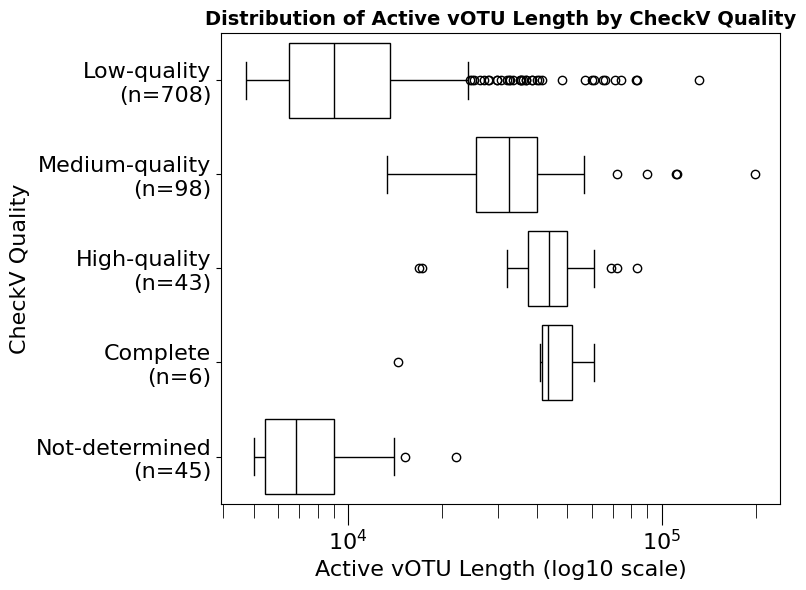

In [6]:
# Create the boxplot with vibrant colors
plt.figure(figsize=(8,6))
ax = sns.boxplot(data=df, x='length', y='checkv_quality',
                 # palette=vibrant_colors[:len(df['checkv_quality'].unique())])
                 color='white', linecolor='black', saturation=1)

# Get counts for each category and add to y-axis labels
category_counts = df['checkv_quality'].value_counts()
y_labels = []
for category in ax.get_yticklabels():
    category_name = category.get_text()
    count = category_counts.get(category_name, 0)
    y_labels.append(f"{category_name}\n(n={count})")

ax.set_yticklabels(y_labels)

# Set x-axis to log10 scale
plt.xscale('log')

# Improve aesthetics
plt.xlabel('Active vOTU Length (log10 scale)', fontsize=16)
plt.ylabel('CheckV Quality', fontsize=16)
plt.xticks(fontsize=16)

# Increase tick length
ax.tick_params(axis='x', which='major', length=15)  # Default is usually 4
ax.tick_params(axis='x', which='minor', length=10)   # For minor ticks if you have them
plt.yticks(fontsize=16)

plt.title('Distribution of Active vOTU Length by CheckV Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Use AI or your own coding abilities to investigate a few more summary statistics
# you think would be important for getting a feel for the quality of your virus sequences.

# Your code here!
...

Ellipsis

## Reflection
Based on these initial summary stats, what does this tell you about the types of sequences we recovered? What kinds of questions can we answer with this distribution of viruses, and what can't we answer? Do you think we found all the active viruses? Does it matter if we missed some?

\<type your answer here\>


It's always good to take stock of your virus sequences and the context of your study. Be realistic and transparent about what kinds of questions you can answer with your data.

Viromics is like a box of chocolates, and you never know quite what you're going to find (especially when mining public data repositories). However, typically our methods are biased towards recovering highly abundant double-stranded DNA phages with relatively low microdiversity, as these sequences appear often enough in our short read data to assemble well. Unless virus-enrichment preps are done, viruses in relatively low copy numbers will only be stochastically recovered.

# Part 2: Manual inspection of virus sequences

**Pick a sequence you were unsure about by filtering the table ‘annotations_df’ and extracting the vOTU name.**

Explore their functional annotations in context with the GeNomad and CheckV scores by filtering the combined GeNomad, CheckV, and DRAMv metadata table in the CoLab notebook. The function is already written, so just change manual_inspect_votu = ‘contig_591846’ to whichever contig you chose. Then run the function and open the CSV in google sheets or excel to parse the metadata and annotations more easily.

**Discuss with a partner what information you are looking for that would inform you if this sequence is a virus or not.**


In [8]:
# contains GeNomad, CheckV, and DRAMv functional annotation metdata
file_name = 'genomad_checkv_dramv_metadata.csv'
path = '/'.join([data_dir, file_name])
votu_annotations = pd.read_csv(path)

In [11]:
manual_inspect_votu = 'contig_591846' # replace with the vOTU name you want to manually inspect.

columns_to_inspect = [
    'vOTU',
    'concat_annotations',
    'gene_position',
    'start_position',
    'end_position',
    'strandedness'# contains all annotations for each tool per gene separated by ';'
    # can add more columns from votu_annotations.columns if you wish
    ]

votu_annotations_subset = votu_annotations[columns_to_inspect]

annotations_df = sh.get_annotations(manual_inspect_votu, votu_annotations_subset)

# Export as a temporary CSV file (which can be opened in the side tab, or downloaded and opened in a table viewer (e.g., Excel, Sheets))
temp_csv_path = f'/content/{manual_inspect_votu}_annotations.csv'
annotations_df.to_csv(temp_csv_path, index=False)
print(f"Annotations exported to: {temp_csv_path}")

# Display the head of the DataFrame to confirm
annotations_df.head()

Annotations exported to: /content/contig_591846_annotations.csv


,vOTU,concat_annotations,gene_position,start_position,end_position,strandedness
5821,contig_591846,rpi:Rpic_4896 acriflavin resistance protein;;...,1.0,3.0,1100.0,1.0
5822,contig_591846,bprl:CL2_29940 putative phage-type endonuclea...,2.0,1917.0,2603.0,1.0
5823,contig_591846,ere:EUBREC_2126 hypothetical protein;YP_00222...,3.0,2613.0,3488.0,1.0
5824,contig_591846,cpas:Clopa_4307 phage recombination protein B...,4.0,3488.0,4189.0,1.0
5825,contig_591846,amt:Amet_2584 hypothetical protein;;Putative ...,5.0,4203.0,4850.0,1.0


While eventually you will be able to visualize the virus from the annotation tables alone, we have written a helper function to visualize them below.

While it's tricky to see all of the annotations, it may give you a better sense for how the genes are arranged.

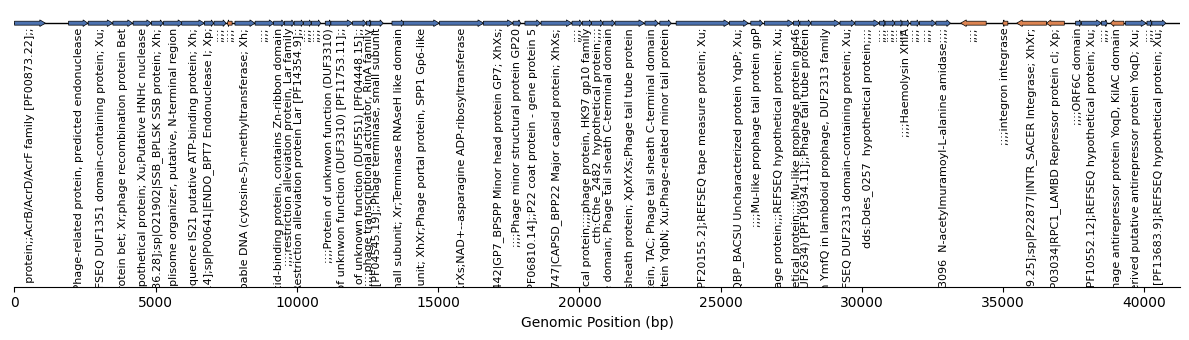

(<Figure size 1200x350 with 1 Axes>, <Axes: xlabel='Genomic Position (bp)'>)

In [13]:
sh.plot_genes(annotations_df,
              label_col='concat_annotations')

## Reflection

Based on the vOTU you inspected, what parts of the metadata and/or annotations made you think it was likely a virus, and which parts made you think it might be something else, if any? (other mobile genetic element or prokaryotic)

**\<type your response here\>**

Researchers can spend significant time and effort trying to optimize their virus identification pipeline. Yet, modern tools achieve >94% accuracy with default settings even on very small sequences (<3kb, see https://www.nature.com/articles/s41587-023-01953-y/figures/3), and minor contamination is often acceptable for many questions. To ensure robust downstream conclusions without spending too much time additionally curating your viral sequence database, prioritize manually inspecting the metadata of high-impact viral sequences (such as the most abundant or differentially abundant) and transparently test the stability of your findings across different filtering strategies if justified (e.g., sequence length, CheckV quality, or confidence score cutoffs). Ad-hoc or unbenchmarked manual curation steps should be avoided unless clearly justified by your specific study context, and pipelining your analysis to evaluate results under multiple cutoffs will ultimately strengthen your conclusions if an unbenchmarked approach is used.


# Part 3a: Does adding catechin to the bioreactor change the alpha diversity of vOTU community activity?

In this section we will compute alpha diversity using the exponential of shannon entropy (Hill number q->1). We use Shannon diversity because it balances bias from rare and highly abundant OTUs.

In [ ]:
from scipy.stats import ttest_ind
import regex as re
import textwrap


In [ ]:
# Load in relative abundance data

# Each row is a sample, and each column is a vOTU.
# Values are the GeTMM relative abundance of each vOTU in each sample.

# Check the methods for what the relative abundance values represent:
# https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3003925
#  -> "vOTU characterizations and analyses"
#     -> "Activity"
file_name = 'votu_relative_abundance.csv'
path = '/'.join([data_dir, file_name])
abundance_df = pd.read_csv(path, index_col=0)
abundance_df.head()

,contig_1000294|provirus_2_36746,contig_1000563,contig_1000567,contig_1000721,contig_1001917,contig_1002679,contig_1002835,contig_1003288,contig_1003639,contig_1004502|provirus_36176_78699,...,contig_989015,contig_989580,contig_989868,contig_989916,contig_990382,contig_991526,contig_992136,contig_994207,contig_996080,contig_998089
STM_0716_E_M_E002,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,13.43498
STM_0716_E_M_E003,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.00000
STM_0716_E_M_E004,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,19.111345,0.00000
STM_0716_E_M_E025,72.464003,48.863221,130.730865,0.0,0.0,11.201407,37.044626,0.0,0.0,0.0,...,0.0,0.000000,16.561061,0.000000,0.0,0.0,0.0,20.784047,0.000000,0.00000
STM_0716_E_M_E027,0.000000,0.000000,69.639630,0.0,0.0,4.963778,10.698596,0.0,0.0,0.0,...,0.0,10.575107,0.000000,4.192528,0.0,0.0,0.0,0.000000,22.383402,0.00000


In [ ]:
# we will use a custom helper function to compute hill numbers,
# but in the real world you can use the scikit-bio/skbio package!

order_num = 1 # change the order to 0 for richness, or to 2 for inverse simpson
alpha_df = (
    abundance_df
    .astype(int)
    .apply(
      lambda x: sh.hill(x, order=order_num),
      axis=1)
    .to_frame(name=f'hill_q{order_num}')
    .reset_index(names='Sample')
)
alpha_df

,Sample,hill_q1
0,STM_0716_E_M_E002,74.240252
1,STM_0716_E_M_E003,37.760374
2,STM_0716_E_M_E004,61.073746
3,STM_0716_E_M_E025,21.518266
4,STM_0716_E_M_E027,30.885755
5,STM_0716_E_M_E033,10.267436
6,STM_0716_E_M_E034,5.968498
7,STM_0716_E_M_E035,6.599608
8,STM_0716_E_M_E050,53.158719
9,STM_0716_E_M_E051,83.820928


In [ ]:
# Merge with additional metadata (treatment, timepoint)

# Sample: Sample ID from JGI sequencing
# treatment: U = Unamended (control), C = Catechin
# timepoint: day the sample was collected from day 0
# total reads: total number of reads sequenced
# prop_mapped: the number of reads that mapped to our vOTUs (computed in https://github.com/jamesriddellv/Grantham_Bioreactor/blob/main/02-get-relative-abundance/scripts/07-alpha_diversity.py)
# hill_q1: the shannon diversity index we just calculated in this notebook

file_name = 'alpha_diversity_metadata.csv'
path = '/'.join([data_dir, file_name])
metadata = pd.read_csv(path)

# merge the alpha diversity values we just calculated to the metadata dataframe
metadata = metadata.merge(alpha_df, on='Sample', how='left')
metadata

,Sample,treatment,timepoint,total reads (R1+R2),prop_mapped,hill_q1
0,STM_0716_E_M_E002,U,0,100000000,0.015945,74.240252
1,STM_0716_E_M_E003,U,0,83017516,0.015798,37.760374
2,STM_0716_E_M_E004,U,0,95400980,0.015470,61.073746
3,STM_0716_E_M_E025,U,14,78691532,0.273177,21.518266
4,STM_0716_E_M_E027,U,14,100000000,0.112260,30.885755
5,STM_0716_E_M_E033,C,14,83168470,0.391475,10.267436
6,STM_0716_E_M_E034,C,14,100000000,1.105661,5.968498
7,STM_0716_E_M_E035,C,14,99235256,1.923247,6.599608
8,STM_0716_E_M_E050,U,21,91608098,0.080747,53.158719
9,STM_0716_E_M_E051,U,21,93570944,0.033067,83.820928


Now that we have wrangled our data, we can visualize alpha diversity (hill_q1) and proportion of reads mapped to viruses (prop_mapped) between treatments and over time

/tmp/ipykernel_566/2108850615.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='treatment', y='hill_q1',
/tmp/ipykernel_566/2108850615.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='treatment', y='prop_mapped',


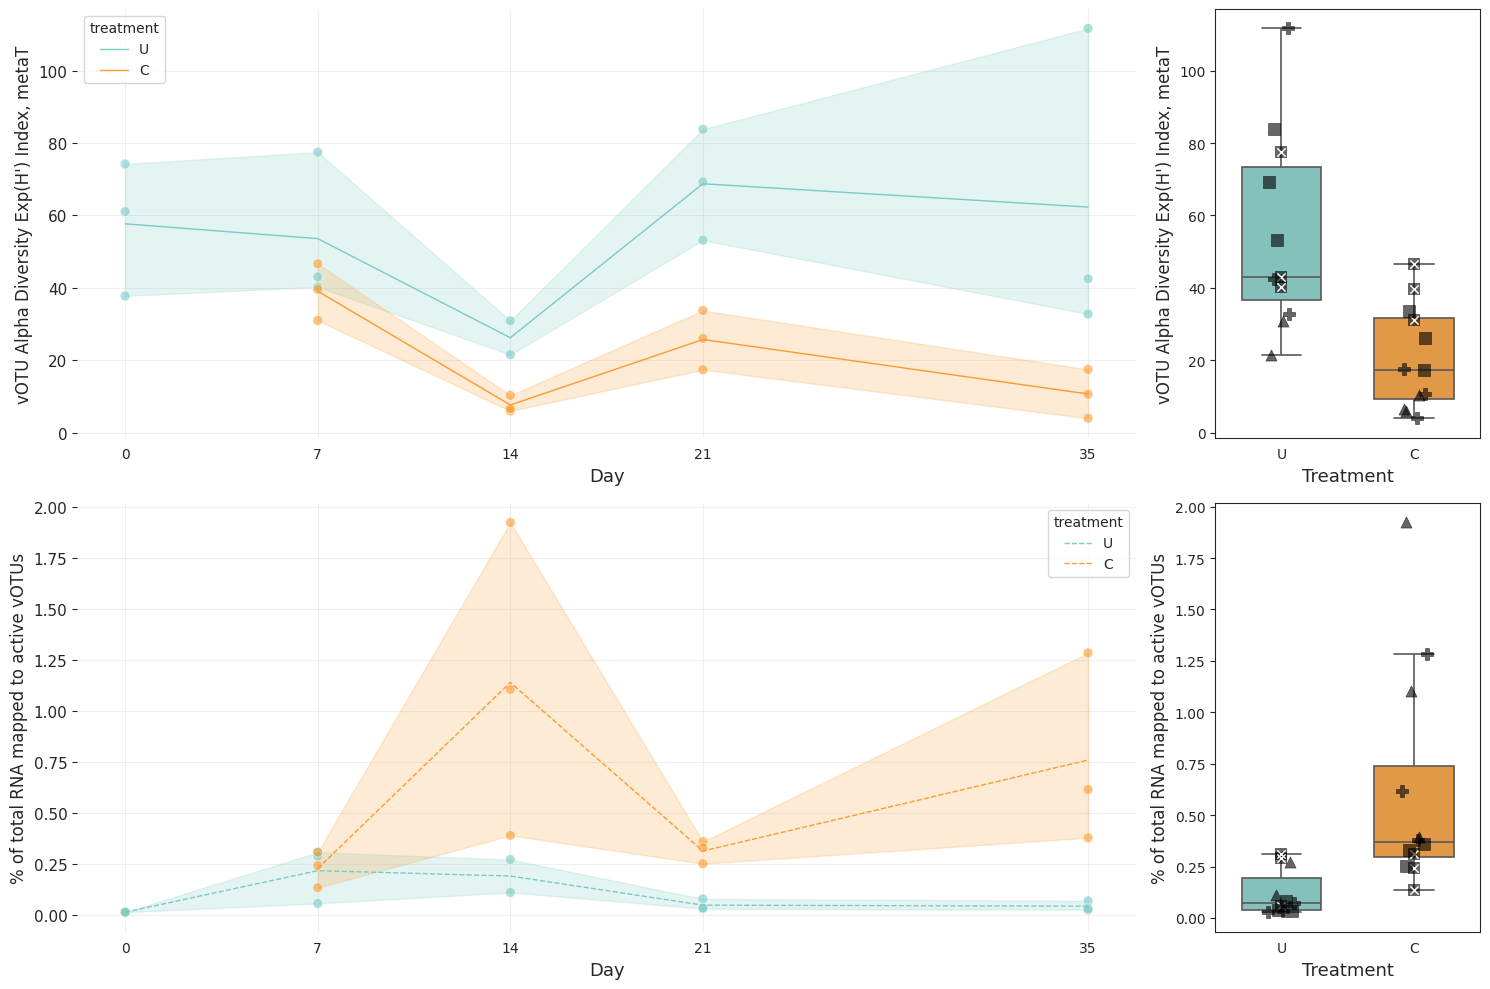

In [ ]:

# ── Label colors for catechin (C) and unamended (U) ───────────────────────────
color_palette = {"C": "#FC9B2D", "U": "#7ACBC3"}

# Create unique markers for each timepoint
marker_map = {"0": "o", "7": "s", "14": "^", "21": "s", "35": "P"}

# ── Shared plot_df ────────────────────────────────────────────────────────────
plot_df = metadata[~((metadata['treatment'] == 'U') & (metadata['timepoint'] == 0))].copy()
plot_df['timepoint_str'] = plot_df['timepoint'].astype(str)


# ── Build 2×2 figure ─────────────────────────────────────────────────────────
sns.set_style("white")

# Create a figure where the first column is 2x the width of the second
fig, axes = plt.subplots(2, 2, figsize=(15, 10),
                        gridspec_kw={'width_ratios': [2, 0.5]})
(ax_tl, ax_tr), (ax_bl, ax_br) = axes

# ── TOP-LEFT: alpha diversity over time ───────────────────────────────────────
sns.lineplot(data=metadata, x='timepoint', y='hill_q1',
             hue='treatment', palette=color_palette,
             estimator='mean', errorbar='ci', linewidth=1,
             legend=True, ax=ax_tl)

sns.scatterplot(data=metadata, x='timepoint', y='hill_q1',
                hue='treatment', palette=color_palette,
                legend=False, ax=ax_tl, s=50, alpha=0.6)

ax_tl.set_xlabel("Day", fontsize=13)
ax_tl.set_ylabel("vOTU Alpha Diversity Exp(H') Index, metaT", fontsize=12)
ax_tl.set_xticks([0, 7, 14, 21, 35])
# Explicitly show y-axis ticks
ax_tl.tick_params(axis='y', which='both', left=True, labelsize=11)
ax_tl.grid(True, alpha=0.3)
for sp in ax_tl.spines.values(): sp.set_visible(False)

# ── BOTTOM-LEFT: prop_mapped over time ────────────────────────────────────────
sns.lineplot(data=metadata, x='timepoint', y='prop_mapped',
             hue='treatment', palette=color_palette,
             estimator='mean', errorbar='ci', linewidth=1, linestyle='--',
             legend=True, ax=ax_bl)

sns.scatterplot(data=metadata, x='timepoint', y='prop_mapped',
                hue='treatment', palette=color_palette,
                legend=False, ax=ax_bl, s=50, alpha=0.6)

ax_bl.set_xlabel("Day", fontsize=13)
ax_bl.set_ylabel("% of total RNA mapped to active vOTUs", fontsize=12)
ax_bl.set_xticks([0, 7, 14, 21, 35])
# Explicitly show y-axis ticks
ax_bl.tick_params(axis='y', which='both', left=True, labelsize=11)
ax_bl.grid(True, alpha=0.3)
for sp in ax_bl.spines.values(): sp.set_visible(False)

# ── TOP-RIGHT: boxplot alpha diversity ────────────────────────────────────────
sns.boxplot(data=plot_df, x='treatment', y='hill_q1',
            palette=color_palette, showfliers=False,
            width=0.6, linewidth=1.2, ax=ax_tr)
sh.add_stripplot(ax_tr, plot_df, 'hill_q1', marker_map)
ax_tr.set_xlabel("Treatment", fontsize=13)
ax_tr.set_ylabel("vOTU Alpha Diversity Exp(H') Index, metaT", fontsize=12)
ax_tr.tick_params(axis='y', left=True) # Ensure ticks show on boxplot

# ── BOTTOM-RIGHT: boxplot prop_mapped ─────────────────────────────────────────
sns.boxplot(data=plot_df, x='treatment', y='prop_mapped',
            palette=color_palette, showfliers=False,
            width=0.6, linewidth=1.2, ax=ax_br)
sh.add_stripplot(ax_br, plot_df, 'prop_mapped', marker_map)
ax_br.set_xlabel("Treatment", fontsize=13)
ax_br.set_ylabel("% of total RNA mapped to active vOTUs", fontsize=12)
ax_br.tick_params(axis='y', left=True) # Ensure ticks show on boxplot

# ── Save ──────────────────────────────────────────────────────────────────────
fig.tight_layout()

plt.show()

## Reflection

Is alpha diversity higher or lower in catechin-treated samples?

**\<type your response here\>**

What about proportion of total RNA that mapped to viruses?

**\<type your response here\>**

What underlying mechanisms (biological or technical) could explain these trends? Discuss with a partner if needed!

**\<type your response here\>**

# Part 3b: Is alpha diversity significantly lower in catechin-treated samples compared to unamended samples?

Now that we have the alpha diversity, we'll run a statistical test to determine if the treatment (or time effect) were significantly different across samples.

Since we are testing two variables, treatment and time, against a single dependent variable, we can use a two-way ANOVA. We need to cast time as a categorical variable to allow for greater flexibility in the model fitting, because for this type of model it is attempting to fit a linear trend, but we can see from the values that this data is not monotonically increasing or decreasing.

We can now test if treatment, time, or their interaction influence alpha diversity. Read here for more! https://en.wikipedia.org/wiki/Two-way_analysis_of_variance

Full transparency: Yes, I asked Gemini to be a biostats expert and tell me what test would be appropriate for this dataset. Yes, I independently verified this test is appropriate by reading more about it on wikipedia and statology. No, I do not know if it is the "best" or most sophisticated test that can be done. We used an even simpler test in the paper, but required making some additional assumptions and normalizations to the data. Please use a more appropriate statistical test if you find this to be incorrect/insufficient and let me know by making a Github pull request!

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Filter out timepoint 0 if desired
df_sub = metadata[metadata['timepoint'] != 0].copy()

# Ensure timepoint is treated as a categorical factor, not a continuous slope
df_sub['timepoint'] = df_sub['timepoint'].astype(str)

# ── 1. Fit Two-Way ANOVA Model ───────────────────────────────────────────────
model = smf.ols('hill_q1 ~ C(treatment) * C(timepoint)', data=df_sub).fit()

# Print ANOVA table (Type II sum of squares)
anova_table = anova_lm(model, typ=2)
print("=== Two-Way ANOVA Table [Alpha Diversity] ===")
print(anova_table)


=== Two-Way ANOVA Table [Alpha Diversity] ===
                                sum_sq    df          F    PR(>F)
C(treatment)               6081.904430   1.0  16.777074  0.000954
C(timepoint)               2862.297036   3.0   2.631904  0.088027
C(treatment):C(timepoint)  1434.234962   3.0   1.318790  0.305160
Residual                   5437.692284  15.0        NaN       NaN


## Reflection
Complete the following statements based on the test results:

Alpha diversity **is/is not** significantly different between **treatments**.

Alpha diversity **is/is not** significantly different between **timepoints**.

The interaction between treatment and timepoint **is/is not** significant for determining alpha diveristy.

### Post-hoc test of assumptions:

We can now check the residuals (error) of the model. If the error is normally distributed and has even variance, then the model is valid and we can trust the results of the test. However, if the error is not normally distributed or does not have even variance (is heteroskedastic), then we fail the test assumptions, and should either transform the data to fit the assumptions of the test or use a different test for which we do satisfy the assumptions for.

In [ ]:
import scipy.stats as stats
import statsmodels.stats.api as sms

# Extract model residuals
residuals = model.resid

# ── 1. Test Normality of Residuals ──────────────────────────────────────────
# Shapiro-Wilk Test (p > 0.05 means residuals are normal)
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")

# ── 2. Test Equal Variance (Homoscedasticity) ───────────────────────────────
# Levene's Test grouped by combined factors
df_sub['group'] = df_sub['treatment'].astype(str) + "_" + df_sub['timepoint'].astype(str)
grouped_residuals = [group['hill_q1'].values for _, group in df_sub.groupby('group')]

levene_stat, levene_p = stats.levene(*grouped_residuals)
print(f"Levene's Test p-value: {levene_p:.4f}")

Shapiro-Wilk p-value: 0.0402
Levene's Test p-value: 0.6555


We slightly fail (p<0.05) the normality assumption (Shapiro-Wilk test) but do pass the homoskedasticity (even variance) assumption. Yes this is sad and frustrating and maybe this test is not the best, but since we barely fail the normality assumption, and our treatment term is highly significant (p<0.001), it's likely the treatment was significant even though we do slightly violate the assumptions of the test. For the study, we used a different test that ignored the effect of time, since we determined it was not significant, but both of these results may be unsatisfactory to you, and you are welcome to try and find a better test!

A quick note and example of statistical power:

We can also show that running welch's t-tests between each timepoint does not yield significance, and we show in the paper that this is due to low power (the ability to see a significant result if one truly exists) because we have so few samples per treatment, and are doing so many tests (which requires correction for false discovery). However, when comparing all samples between the two treatments, we do have sufficient statistical power, and from the test are able to conclude that the vOTU community activity in catechin amended samples is significantly less diverse than in unamended samples.

In [ ]:
# ── Post-hoc comparisons per timepoint ───
from statsmodels.stats.multitest import multipletests

print("\n=== Pairwise Treatment Comparisons per Timepoint ===")
timepoints = sorted(df_sub['timepoint'].unique(), key=int)
p_vals = []

for tp in timepoints:
    sub = df_sub[df_sub['timepoint'] == tp]
    cat = sub[sub['treatment'] == 'C']['hill_q1']
    una = sub[sub['treatment'] == 'U']['hill_q1']

    # Welch's t-test at this specific timepoint
    t_stat, p_val = stats.ttest_ind(cat, una, equal_var=False)
    p_vals.append(p_val)
    print(f"Timepoint {tp}: t = {t_stat:.3f}, unadjusted p = {p_val:.4f}")

# Adjust p-values for 4 tests (Day 7, 14, 21, 35) using Benjamini-Hochberg FDR
_, p_adj, _, _ = multipletests(p_vals, method='fdr_bh')
for tp, adj_p in zip(timepoints, p_adj):
    print(f"  → Day {tp} FDR-adjusted p = {adj_p:.4f}")


=== Pairwise Treatment Comparisons per Timepoint ===
Timepoint 7: t = -1.134, unadjusted p = 0.3516
Timepoint 14: t = -3.816, unadjusted p = 0.1348
Timepoint 21: t = -4.290, unadjusted p = 0.0225
Timepoint 35: t = -2.054, unadjusted p = 0.1703
  → Day 7 FDR-adjusted p = 0.3516
  → Day 14 FDR-adjusted p = 0.2270
  → Day 21 FDR-adjusted p = 0.0899
  → Day 35 FDR-adjusted p = 0.2270


Here is the final plot used in the actual study and can double-check your visualization against it. The statistics will be different since we used a different test (z-scored alphaD to make it more normally distributed before applying welch's t-test, and assumed time was not a significant variable).

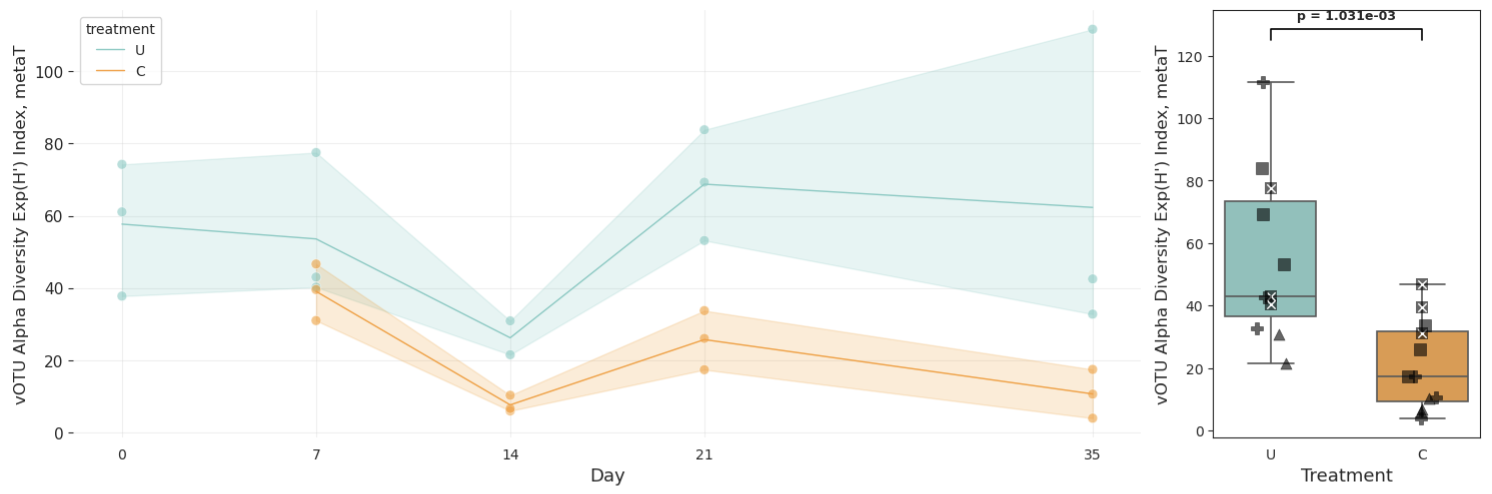

# Part 4: Beta Diversity - at what point does the catechin treatment significantly alter vOTU community expression?

In this next section, we will figure out how similar/different each of our samples are, and test if the vOTU community activity in catechin-treated samples are significantly different from unamended samples.

We are going to take the GeTMM relative abundance table and calculate the Bray-Curtis dissimilarity between each sample. From these dissimilarity values, we will use dimensionality reduction to visualize the distance between each sample based on the vOTU community activity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from matplotlib.lines import Line2D

# Instead of using the below packages to avoid installing more stuff,
# we have custom-built functions in stats_helpers.py that do nearly the same
# calculations.

# from skbio.stats.distance import anosim, DistanceMatrix


For the following code block, read through each block to understand why each transformation was done. Please ask questions if you would like something clarified!

/tmp/ipykernel_566/2820575026.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Cluster 1 (Day 7 pre-response)' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metadata.loc[c1_mask, 'formal_cluster'] = "Cluster 1 (Day 7 pre-response)"


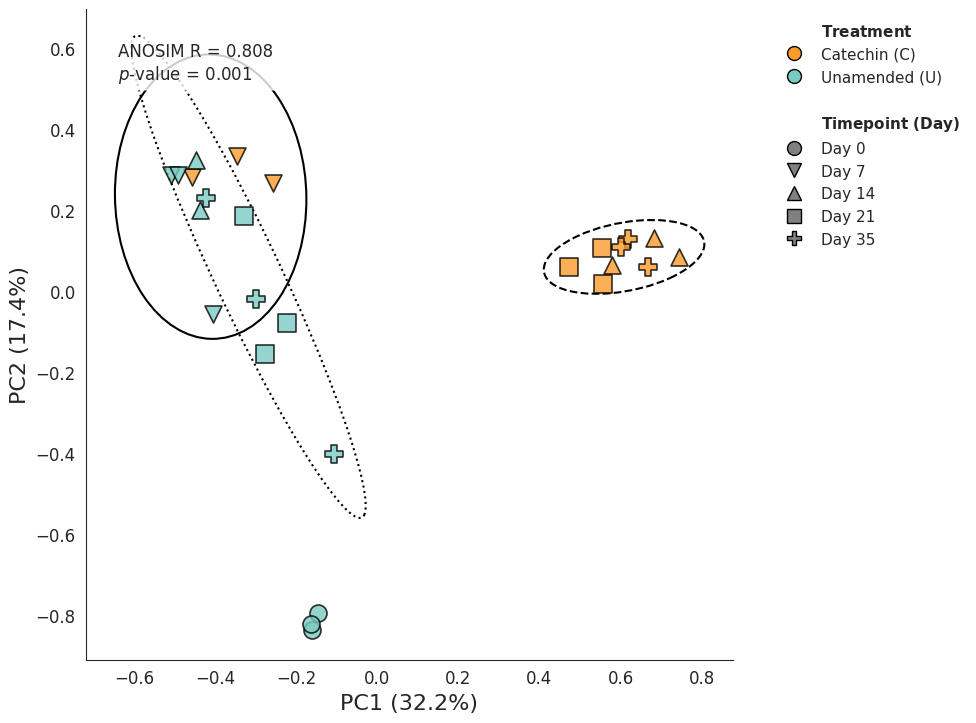

In [ ]:

# ── 1. Load and Prepare Data ──────────────────────────────────────────────────
# RATIONALE: Environmental viral community datasets (vOTU counts) suffer from high
# technical variability across sequencing runs and library preparations.
# Explicit alignment of sample identifiers and metadata filtering ensures strict
# experimental unit control prior to ordination and statistical testing.

counts_path = '/'.join([data_dir, '/getmms_REV_5x_vOTUs_corrected_wide.tsv'])
meta_path = '/'.join([data_dir, 'metaT_sample_metadata.csv'])

# Load vOTU (viral Operational Taxonomic Unit) abundance matrix and metadata
counts_df = pd.read_csv(counts_path, sep='\t').set_index('vOTU')
metadata = pd.read_csv(meta_path)

# Remove additional treatment condensed tannin (CT) to isolate the experimental perturbation
# dynamics (catechin amendment vs. unamended control).
metadata = metadata[metadata['treatment'] != 'CT'].copy()
metadata['treatment'] = metadata['treatment'].replace({'unamended': 'U', 'catechin': 'C'})

# Construct unique sample IDs following [Treatment]_[Timepoint]_[Replicate] logic.
# Replicating R's `make.unique` behavior via `.cumcount()` prevents misgrouping
# during downstream distance matrix generation.
sample_ids = metadata['treatment'] + '_' + metadata['timepoint'].astype(str)
sample_ids = sample_ids + '_' + metadata.groupby(sample_ids).cumcount().astype(str)
metadata.index = sample_ids

# Transpose the count matrix so that samples are rows (N) and vOTUs are columns (P).
# Ordination algorithms and distance metrics expect observations in rows and features in columns.
t_df = counts_df.T
t_df.index = sample_ids

# ── 2. Transformation (Hellinger) ─────────────────────────────────────────────
# RATIONALE: Ecological count data exhibit the "double-zero problem" (two samples
# sharing zeros for a vOTU does NOT mean they are ecologically similar; the virus
# may simply be undetected or absent due to stochastic sampling). Standard Euclidean
# metrics (e.g., PCA) treat shared zeros as similarity, distorting ordination.
#
# The Hellinger transformation breaks down into two steps:
# 1. Relative abundance (Standardization by total sum): Controls for unequal sequencing
#    depth across library prep runs.
# 2. Square-root transformation: Downweights hyper-abundant viral taxa (reducing
#    skewness) and renders Euclidean distances on Hellinger-transformed data equivalent
#    to Hellinger distances. This allows us to safely use linear ordination techniques
#    like PCA without horseshoe artifacts.

row_sums = t_df.sum(axis=1)
rel_abund = t_df.div(row_sums, axis=0) # Step 1: Normalize sequencing depth
hel_df = np.sqrt(rel_abund)             # Step 2: Hellinger square-root transform

# ── 3. Define Formal Clusters ─────────────────────────────────────────────────
# RATIONALE: To test specific biological hypotheses (e.g., "Is there a distinct
# temporal response trajectory between treatments?"), samples are grouped into a priori
# functional response states based on experimental phase (e.g., lag phase vs. succession phase).

metadata['day'] = metadata['timepoint'].str.replace('day', '').astype(int)
metadata['formal_cluster'] = np.nan

# Cluster Logic Masks:
# Cluster 1: Baseline/lag phase (Day 7 for both treatments prior to the methane response period based on gas data)
# Cluster 2: Catechin response trajectory (Days 14–35)
# Cluster 3: Unamended baseline trajectory (Days 14–35)
c1_mask = ((metadata['treatment'] == 'C') & (metadata['day'] == 7)) | \
          ((metadata['treatment'] == 'U') & (metadata['day'] == 7))
c2_mask = (metadata['treatment'] == 'C') & (metadata['day'].isin([14, 21, 35]))
c3_mask = (metadata['treatment'] == 'U') & (metadata['day'].isin([14, 21, 35]))

metadata.loc[c1_mask, 'formal_cluster'] = "Cluster 1 (Day 7 pre-response)"
metadata.loc[c2_mask, 'formal_cluster'] = "Cluster 2 (C response)"
metadata.loc[c3_mask, 'formal_cluster'] = "Cluster 3 (U response)"

# ── 4. Statistical Testing (ANOSIM) ───────────────────────────────────────────
# RATIONALE:
# 1. Metric Selection (Bray-Curtis): Bray-Curtis dissimilarity measures compositional
#    turnover between community samples, ranging from 0 (identical) to 1 (no shared taxa).
# 2. Test Selection (ANOSIM): Analysis of Similarities is a non-parametric permutation-based
#    test designed to test whether community dissimilarity between predefined groups
#    is significantly greater than within-group dissimilarity.
#
# Test Statistic Interpretation:
# - ANOSIM R statistic ranges from -1 to 1:
#   * R ≈ 1: Complete separation (between-group dissimilarity >> within-group dissimilarity).
#   * R ≈ 0: No group structure (null hypothesis holds true; high overlap).
#   * R < 0: Within-group variation is larger than between-group variation (rare; implies
#     improper grouping or extreme sampling artifacts).

# Filter dataset to samples with an assigned formal cluster
test_idx = metadata['formal_cluster'].notna()
meta_filt = metadata[test_idx].copy()
hel_filt = hel_df[test_idx].copy()

# Compute the Bray-Curtis dissimilarity matrix on Hellinger-transformed counts
bray_dist_array = pdist(hel_filt, metric='braycurtis')
bray_dist_matrix = sh.DistanceMatrix(squareform(bray_dist_array), ids=meta_filt.index)

# Run Global ANOSIM with 999 Monte Carlo permutations to assess statistical significance (p-value)
anosim_res = sh.anosim(bray_dist_matrix, meta_filt['formal_cluster'], permutations=999)
anosim_R = anosim_res['test statistic']
anosim_p = anosim_res['p-value']

# ── 5. PCA Projection ─────────────────────────────────────────────────────────
# RATIONALE: Principal Component Analysis (PCA) is an unsupervised linear dimension
# reduction technique. Because we previously transformed the data using the Hellinger method,
# performing a standard Euclidean PCA here is mathematically equivalent to a Hellinger
# Ordination (tb-PCA / transformation-based PCA).
#
# This allows us to reduce high-dimensional vOTU space (thousands of viral taxa)
# into 2 orthogonal axes (PC1, PC2) that capture maximum variance without suffering
# from the zero-inflation distortions typical of raw count matrices.

pca = PCA(n_components=2)
pcs = pca.fit_transform(hel_df)

# Calculate percentage of total community variance explained by the first two PCs
pct_var = np.round(pca.explained_variance_ratio_ * 100, 1)

# Create new columns in the metadata table matching PC1 and PC2.
metadata['PC1'] = pcs[:, 0]
metadata['PC2'] = pcs[:, 1]

# ── 6. Plotting ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 8))  # Slightly wider to comfortably accommodate legend

cols_dict = {"C": "#FC9B2D", "U": "#7ACBC3"}
markers_dict = {0: 'o', 7: 'v', 14: '^', 21: 's', 35: 'P'}  # Swapped '+' to 'P' (filled plus) for better visibility
line_styles = {
    "Cluster 1 (Day 7 pre-response)": "solid",
    "Cluster 2 (C response)": "dashed",
    "Cluster 3 (U response)": "dotted"
}

# 1. Draw confidence ellipses
for cluster_name in metadata['formal_cluster'].dropna().unique():
    cluster_data = metadata[metadata['formal_cluster'] == cluster_name]
    sh.add_confidence_ellipse(
        cluster_data['PC1'], cluster_data['PC2'], ax,
        edgecolor="black",
        linestyle=line_styles[cluster_name],
        linewidth=1.5
    )

# 2. Draw scatter points
for (treatment, day), group_data in metadata.groupby(['treatment', 'day']):
    ax.scatter(
        group_data['PC1'], group_data['PC2'],
        c=cols_dict.get(treatment, 'gray'),
        marker=markers_dict.get(day, 'o'),
        s=150, alpha=0.8, edgecolor='black', linewidth=1.2
    )

# 3. Create Custom Legend Elements
legend_elements = []

# --- Treatment Legend (Color) ---
legend_elements.append(Line2D([0], [0], color='none', label=r'$\bf{Treatment}$'))  # Section Header
for trt, color in cols_dict.items():
    trt_name = "Catechin (C)" if trt == "C" else "Unamended (U)"
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=trt_name,
               markerfacecolor=color, markeredgecolor='black', markersize=10)
    )

# Spacer between legend groups
legend_elements.append(Line2D([0], [0], color='none', label=''))

# --- Day Legend (Shape) ---
legend_elements.append(Line2D([0], [0], color='none', label=r'$\bf{Timepoint\ (Day)}$'))  # Section Header
for day, marker in sorted(markers_dict.items()):
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='w', label=f"Day {day}",
               markerfacecolor='gray', markeredgecolor='black', markersize=10)
    )

# 4. Add Legend to Plot
ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    fontsize=11
)

# 5. Axes Formatting
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(f"PC1 ({pct_var[0]}%)", fontsize=16)
ax.set_ylabel(f"PC2 ({pct_var[1]}%)", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)

# Stats Annotation (Top Left)
stats_text = f"ANOSIM R = {anosim_R:.3f}\n$p$-value = {anosim_p:.3f}"
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

sns.despine()
plt.tight_layout()
plt.show()

## Reflection

1. What can you conclude based on these beta diversity results? What can we conclude now that we couldn't with the alpha diversity results alone?

**\<type your response here\>**

2. Why do you think day 0 is so different from all the other samples?

**\<type your response here\>**

3. At what timepoint would you say catechin is having an effect on the vOTU community activity?

**\<type your response here\>**

*Note* -- The graph will look slightly different from the published version since the code was translated from R to Python and uses a different set of packages for the dissimilarity calculation and visualization. Yet, the result should still show that catechin samples day 14-35 are significantly different from all other samples.

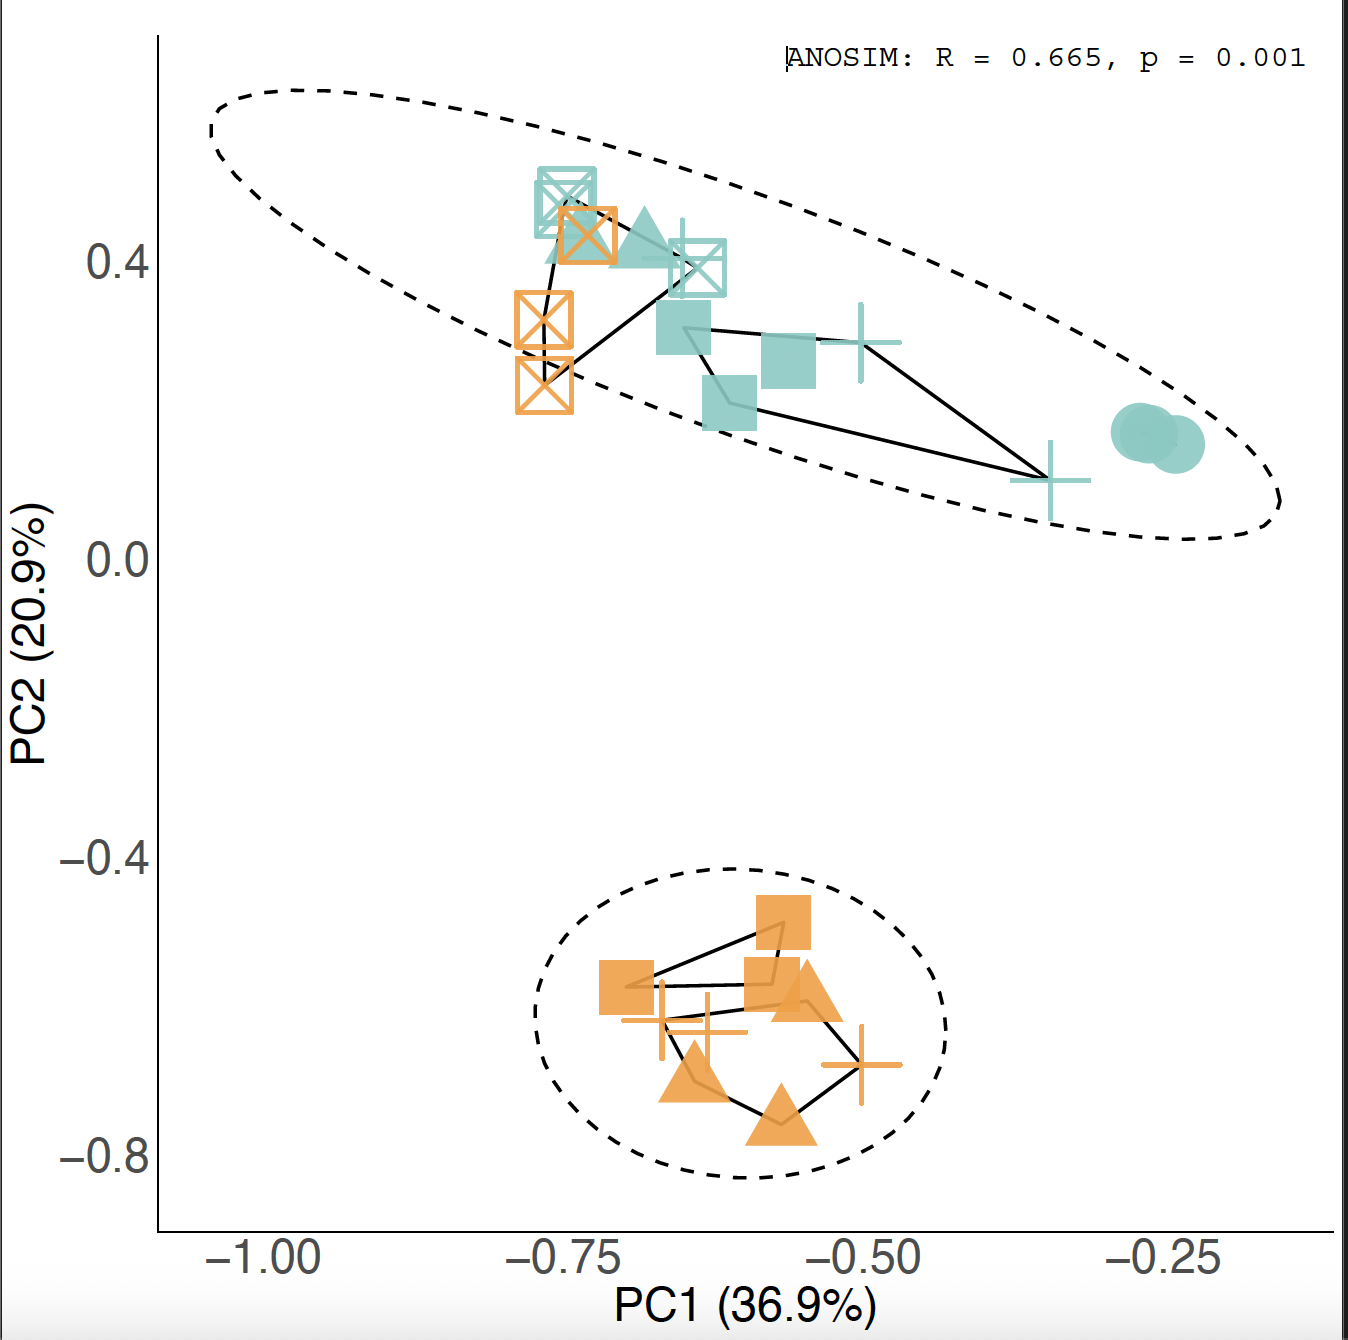